In [2]:
!pip install tensorflow

In [3]:
# Chest X-ray CNN  Normal / Pneumonia 
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
train_dir =r'C:\Users\Priyadharshini\Desktop\Final project health\DAta\chest_xray\chest_xray\train'
val_dir   = r'C:\Users\Priyadharshini\Desktop\Final project health\DAta\chest_xray\chest_xray\val'
test_dir  = r'C:\Users\Priyadharshini\Desktop\Final project health\DAta\chest_xray\chest_xray\test'

In [5]:
img_size = (224,224)      
batch_size = 16
epochs = 5

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
# Image Data Generators

train_datagen = ImageDataGenerator(rescale=1./255) 
val_datagen   = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size,
    class_mode='binary', shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size,
    class_mode='binary', shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [8]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout

In [9]:
img_size = (224, 224) 

In [10]:
 ##CNN Model

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size[0], img_size[1],3)),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  
])


c:\Users\Priyadharshini\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 111, 111, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 54, 54, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
# Train the Model

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs
)

Epoch 1/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 228s 693ms/step - accuracy: 0.9371 - loss: 0.1998 - val_accuracy: 0.5000 - val_loss: 8.8106
Epoch 2/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 217s 666ms/step - accuracy: 0.9666 - loss: 0.0950 - val_accuracy: 0.6250 - val_loss: 3.7525
Epoch 3/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 164s 504ms/step - accuracy: 0.9778 - loss: 0.0615 - val_accuracy: 0.8125 - val_loss: 0.4265
Epoch 4/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 181s 555ms/step - accuracy: 0.9843 - loss: 0.0478 - val_accuracy: 1.0000 - val_loss: 0.0821
Epoch 5/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 173s 530ms/step - accuracy: 0.9854 - loss: 0.0423 - val_accuracy: 1.0000 - val_loss: 0.0264


In [14]:
# Evaluate on Test Set

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=1,
    class_mode='binary', shuffle=False
)

pred_prob = model.predict(test_gen)
pred = (pred_prob > 0.5).astype(int)
true_labels = test_gen.classes

Found 624 images belonging to 2 classes.
624/624 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step


              precision    recall  f1-score   support

      NORMAL       0.95      0.54      0.69       234
   PNEUMONIA       0.78      0.98      0.87       390

    accuracy                           0.82       624
   macro avg       0.86      0.76      0.78       624
weighted avg       0.84      0.82      0.80       624



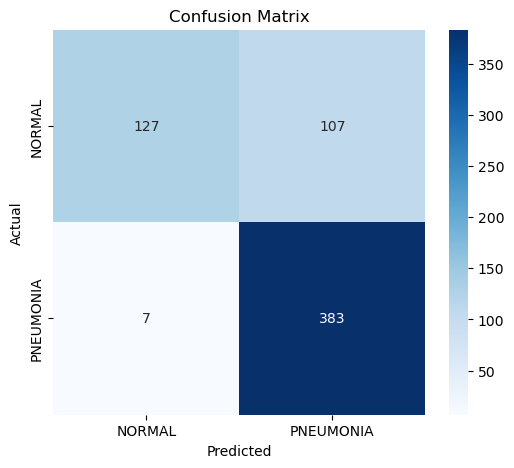

In [15]:
# Classification Report
print(classification_report(true_labels, pred, target_names=list(test_gen.class_indices.keys())))

# Confusion Matrix
cm = confusion_matrix(true_labels, pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys(), cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

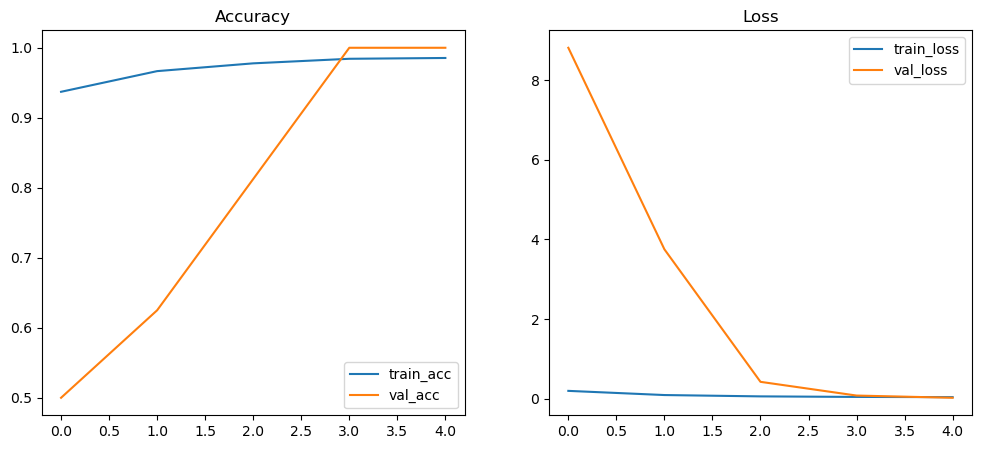

In [16]:
# Plot Accuracy and Loss

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()
plt.show()


In [18]:
# Save trained CNN model
model.save("D:/final_project/models/pneumonia_cnn_final.h5")
print("CNN Model Saved Successfully!")


CNN Model Saved Successfully!
